In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('source/FReDA4.csv')
df = df[df["Role"] == "Anchor"].dropna()

In [3]:
o = df['Relationship Length (years)'].quantile(0.15)
p = df['Relationship Length (years)'].quantile(0.50)
q = df['Relationship Length (years)'].quantile(0.75)

In [4]:
def len_to_bins(val):
    if val <= 2.5:
        return "Short (2.5 years)"
    elif val <= 10:
        return "Medium (10 years)"
    else:
        return "Long (10+ years)"

df['Relationship Length (bins)'] = df['Relationship Length (years)'].apply(len_to_bins)

In [7]:
pd.crosstab(df["Group3"], df["Relationship Length"])

Relationship Length,1.0,2.0,3.0,4.0,5.0
Group3,,,,,
Couple Deprivation,248,496,975,1366,590
Couple Mixed,33,54,74,95,30
Couple Oversaturation,54,64,94,71,33
Couple Satisfaction,226,324,425,455,220


In [44]:
df.rename(columns={'Relationship Length (years)':'Relationship_length_years'}, inplace=True)

In [45]:
import statsmodels.formula.api as smf

model = smf.ols('Frequency ~ Age * Relationship_length_years', data=df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              Frequency   R-squared:                       0.102
Model:                            OLS   Adj. R-squared:                  0.101
Method:                 Least Squares   F-statistic:                     224.0
Date:                Mon, 03 Aug 2026   Prob (F-statistic):          1.24e-137
Time:                        16:11:58   Log-Likelihood:                -9592.9
No. Observations:                5927   AIC:                         1.919e+04
Df Residuals:                    5923   BIC:                         1.922e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [46]:
pal = [
    '#C87A5E',
    '#6D947B',
    '#84739E'
]

order = [
    "Short (2.5 years)",
    "Medium (10 years)",
    "Long (10+ years)"
]


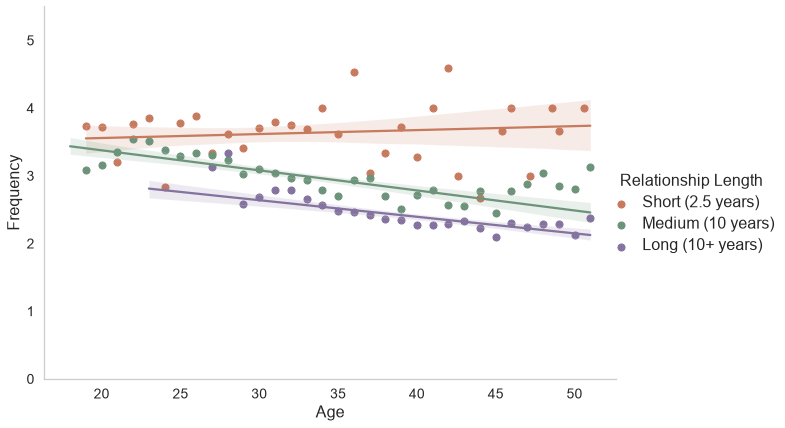

In [49]:
g = sns.lmplot(
    data=df,
    x="Age",
    x_ci=None,
    x_bins=300,
    y="Frequency",
    hue="Relationship Length (bins)",
    hue_order=order,
    palette=pal,

    height=6,
    aspect=1.5,

    # logx=True,
)

plt.xlabel("Age", fontsize=16)
plt.ylabel("Frequency", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(False)

g._legend.set_title("Relationship Length")

plt.setp(g._legend.get_texts(), fontsize=16)
plt.setp(g._legend.get_title(), fontsize=16)

plt.ylim([0, 5.5])

# plt.savefig('output/img/paper/age2.png', dpi=600, transparent=False, bbox_inches='tight')

plt.show()